In [81]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [82]:
api = wandb.Api()

In [83]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s13/experiments/distillation-layerwise/run5-full"

In [84]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    arr_lambda_layer,
    dataset,
    training_size,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": {"$in": arr_lambda_layer}},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.dataset": dataset},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        
        k = np.argmax(run.summary["arr_metrics"]["val_acc"]["value"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"]["value"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"]["value"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"]["value"][k]


        rows.append(
            dict(
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    
    df = pd.DataFrame(rows)
    
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
    lambda_task=0.0,
    lambda_kd=1.0,
    arr_lambda_layer=[0.0, 0.1, 100, 1.0],
    policy="basis-student-linearnbinner:pca--uncentered",
    training_size=1.0,
    verbose=True,
    dataset="cifar100-people",

)

summary

we have 19 runs
df.shape: (4, 11)


lambda_layer val_acc                 val_agreement                  \
                  mean       std count          mean       std count   
0          0.0  0.5225  0.012261     4        0.5160  0.015055     4   
1          0.1  0.5340  0.012329     5        0.5308  0.010545     5   
2          1.0  0.5280  0.013416     5        0.5108  0.017978     5   
3        100.0  0.6248  0.002280     5        0.6644  0.015710     5   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                           0.3990  0.010893     4       0.624  
1                           0.4140  0.009695     5       0.624  
2                           0.4004  0.015258     5       0.624  
3                           0.4968  0.007294     5       0.624

# Comparison on `cifar100-resnet18-wb15`

[warning] policy=basis-student-linearnbinner:pca--uncentered: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:prca-sortabs--uncentered: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:random--uncentered: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=vid: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=attention-transfer: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=fitnetinvid: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=fitnetinvidinner: [4 5 5 5 5 5 5 5 5 5]


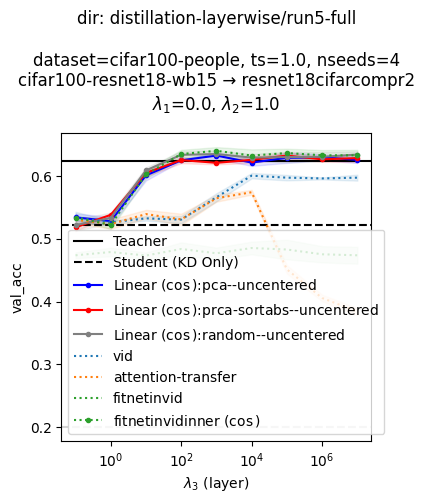

In [78]:
def ls(policy):
    if policy in ["fitnetinvid", "fitnetinvidinner", "attention-transfer", "vid"] :
        return ":"
    else:
        return "-"
    
def marker(policy):
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-student-linearnbinner", "Linear ($\cos$)") \
        .replace("fitnetinvidinner", "fitnetinvidinner ($\cos$)")

    
    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher, student, basis_mode="uncentered", show_legend=True,
    training_size=1.0
):
        
    dataset = "cifar100-people"
    lambda_kd = 1.0
    lambda_task = 0.0
    arr_lambda_layer = [
        0, 0.001, 0.01, 
        0.1, 1.0, 10.0,
        100.0, 
        1000.0, 10000.0,
        100000.0,
        1_000_000.0,
        10_000_000.0, 
#         100_000_000.0
    ]
        
    policies = [ 
        f"basis-student-linearnbinner:pca--{basis_mode}",
        f"basis-student-linearnbinner:prca-sortabs--{basis_mode}",
        f"basis-student-linearnbinner:random--{basis_mode}",
        "vid",
        "attention-transfer",
        "fitnetinvid",
        "fitnetinvidinner",
    ]

    
    arr_lambda_layer = arr_lambda_layer
    policies = policies
        

    col = "val_acc"
    
    ncols = 1
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    for pix, policy in enumerate(policies):
        df = read_data(
            teacher=teacher,
            student=student,
            policy=policy,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            arr_lambda_layer=arr_lambda_layer,
            dataset=dataset,
            training_size=training_size,
            verbose=False
        )
        
        if count == None:
            
#             np.testing.assert_equal(
#                 df[col]["count"].values,
#                 df[col]["count"].values[0]
#             )

            count = df[col]["count"].values[0]
        else:
#             np.testing.assert_equal(df[col]["count"].values, count)  
            pass 
        if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
            or df[col]["count"].values[0] != count:
                print(f"[warning] policy={policy}:", df[col]["count"].values)    
#         print(f"[policy={policy}]:count=",df[col]["count"].values)
        
        if pix == 0:
            plt.axhline(
                df["teacher_acc"].values[-1],
                ls="-",
                color="k",
                label="Teacher"
            )
            
            plt.axhline(
                df[col]["mean"].values[0],
                ls="--",
                color="k",
                label="Student (KD Only)"
            )
            plt.axhline(0.2, ls="--", color="lightgray")
        
        # here, we use [1:] to excluding lambda_layer=0
        assert df["lambda_layer"][0] == 0.0
        ticks = df["lambda_layer"][1:]
        mean = df[col]["mean"][1:]
        stderr = df[col]["std"][1:] / (count ** 0.5)
        
        plt.plot(
            ticks,
            mean,
            marker=marker(policy),
            label=alias(policy),
            ls=ls(policy),
            color=color(policy)
        )
        
        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )
        
    
 

    plt.xscale("log")
    plt.xlabel("$\lambda_3$ (layer)")
    plt.ylabel(col)
    if show_legend:
        plt.legend()
    plt.title(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"dataset={dataset}, ts={training_size}, nseeds={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}"
        ]),
        y=1.05,
    )

viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
) 

# Comparing Across Compressed Students

[warning] policy=basis-student-linearnbinner:pca--uncentered: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:prca-sortabs--uncentered: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:random--uncentered: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=vid: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=attention-transfer: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=fitnetinvid: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=fitnetinvidinner: [4 5 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:pca--uncentered: [4 5 5 3 5 4 5 4 5 4]
[warning] policy=basis-student-linearnbinner:prca-sortabs--uncentered: [4 5 5 3 5 4 5 4 5 4]
[warning] policy=basis-student-linearnbinner:random--uncentered: [4 5 5 3 5 4 5 4 5 4]
[warning] policy=vid: [4 5 5 3 5 4 5 4 5 4]
[warning] policy=attention-transfer: [4 5 5 3 5 4 5 4 5 4]
[warning] policy=fitnetinvid: [4 5 5 3 5 4 5 4 5 4]
[warning] policy=fitnetinvidinner: [4 5 5 3 5 4 5 4 5 4]


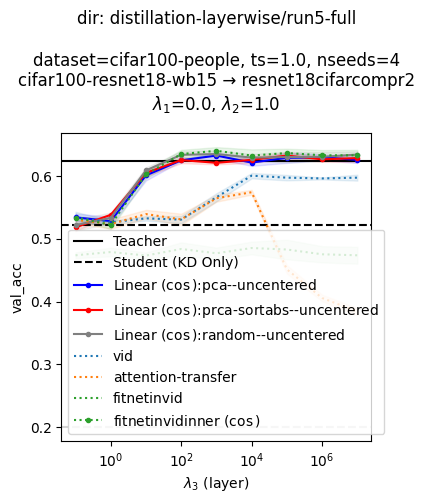

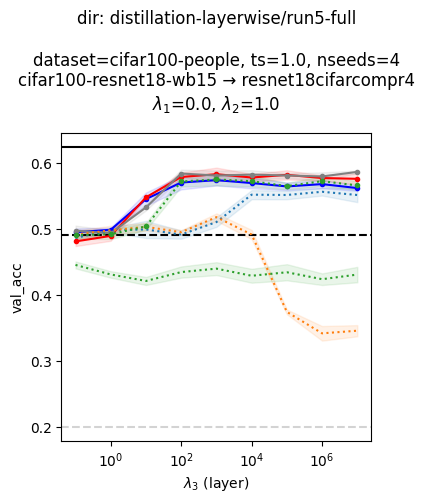

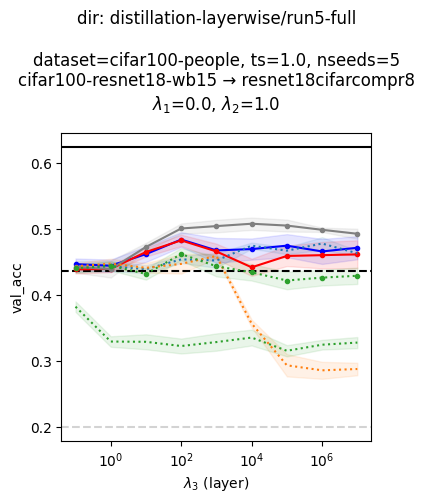

In [85]:
for six, student in enumerate(["resnet18cifarcompr2", "resnet18cifarcompr4", "resnet18cifarcompr8"]):
    
    viz_distillation(
        teacher = "cifar100-resnet18-wb15",
        student=student,
        show_legend=six==0,
        training_size=1.0
    ) 

[warning] policy=basis-student-linearnbinner:pca--uncentered: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=basis-student-linearnbinner:prca-sortabs--uncentered: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=basis-student-linearnbinner:random--uncentered: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=vid: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=attention-transfer: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=fitnetinvid: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=fitnetinvidinner: [4 3 5 5 5 5 5 5 4 5]
[warning] policy=basis-student-linearnbinner:pca--uncentered: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:prca-sortabs--uncentered: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:random--uncentered: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=vid: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=attention-transfer: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=fitnetinvid: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=fitnetinvidinner: [5 4 5 5 5 5 5 5 5 5]
[warning] policy=basis-student-linearnbinner:pca

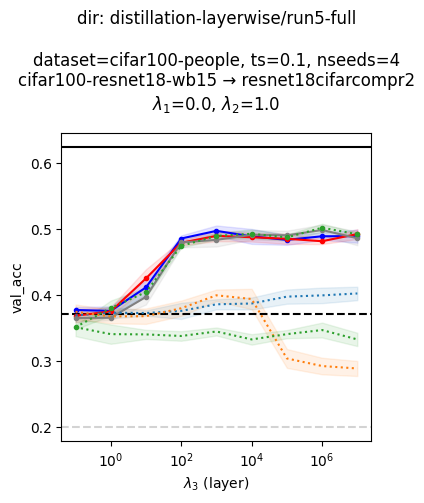

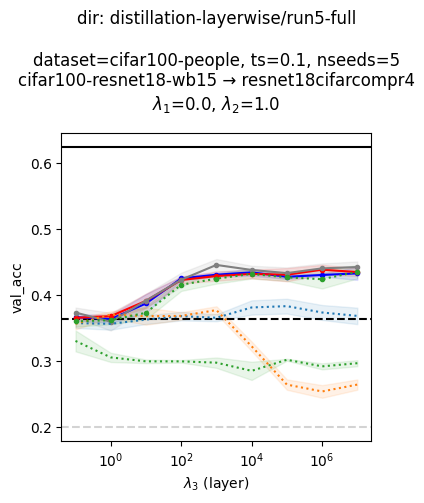

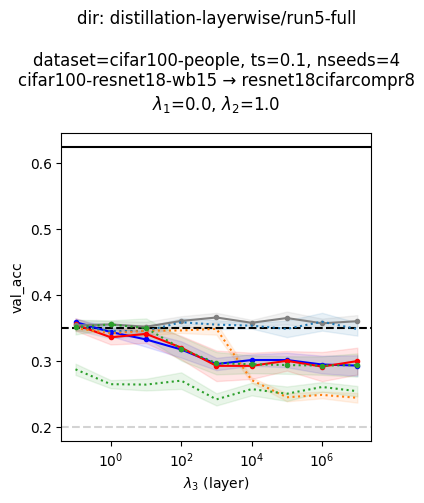

In [87]:
for six, student in enumerate(["resnet18cifarcompr2", "resnet18cifarcompr4", "resnet18cifarcompr8"]):
    
    viz_distillation(
        teacher = "cifar100-resnet18-wb15",
        student=student,
        show_legend=False,
        training_size=0.1, # waiting training-size=1.0
    ) 

# Comparing Centering using `student=resnet18cifarcustomized`

In [63]:
# for bix, basis_mode in enumerate(["centered", "uncentered"]):
#     viz_distillation(
#         teacher = "cifar100-resnet18-wb15",
#         student="resnet18cifarcustomized",
#         basis_mode=basis_mode,
#         show_legend=True
#     ) 

# Summary

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^5\}$

*Aims:* 
- investigate the influence of $\lambda_3$ across different layer distillation polices and student models.


*Conclusion:*
- the accuracy of `policy=basis:{pca,prca-sortabs}` peaks at the same `\lambda_3`.
- `policy=basis:random` works quite well if the $\lambda_3$ is chosen properly.
- `policy={attention-transfer,vid}` requires quite large $\lambda_3$. This might be just a matter of scaling. One could try to paramerize $\hat{\lambda}_3 = 10^2 \cdot \lambda_3$.
- when `training-size=1.0`, it is NOT conclusive that `policy=basis:prca-sortabs` is benefitial.

*Remark*: 
- Currently, the accuracy comes from the validation set. Preferbably, we repeat this again using a proper validation/test set.